In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings("ignore")

In [2]:
iris = load_iris()
X = iris.data          # Features: sepal length, sepal width, petal length, petal width
y_true = iris.target   # True species (not used for clustering, only for comparison)
feature_names = iris.feature_names


In [3]:
print("Dataset shape:", X.shape)
print("Features:", feature_names)

# Standardize features (important for K‑Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


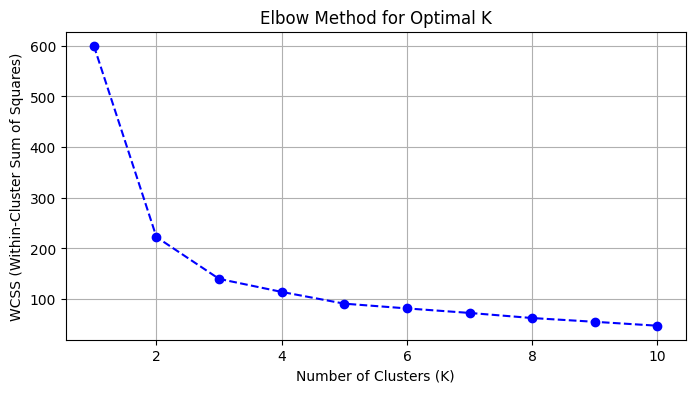

In [6]:
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

In [7]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels = kmeans.labels_
centroids_scaled = kmeans.cluster_centers_

# Transform centroids back to original scale for interpretation
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=feature_names)
print("\nCluster centroids (original scale):")
print(centroids_df)


Cluster centroids (original scale):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           5.801887          2.673585           4.369811          1.413208
1           5.006000          3.428000           1.462000          0.246000
2           6.780851          3.095745           5.510638          1.972340


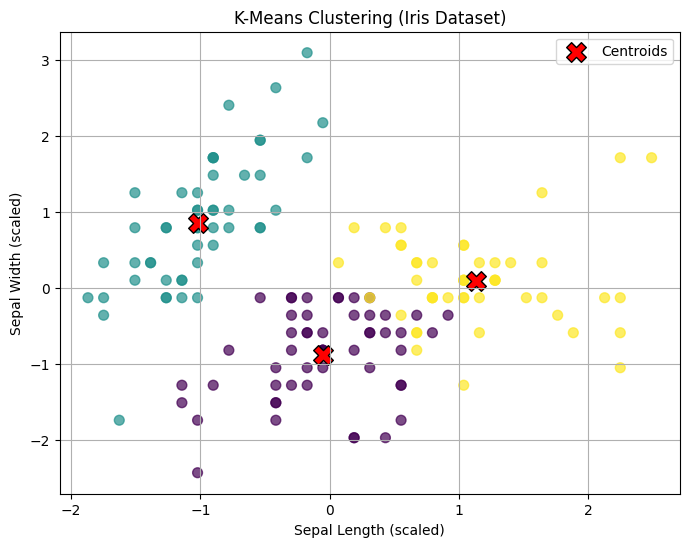

In [8]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(centroids_scaled[:, 0], centroids_scaled[:, 1], marker='X', s=200, c='red', edgecolors='black', label='Centroids')
plt.title('K-Means Clustering (Iris Dataset)')
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.legend()
plt.grid(True)
plt.show()


In [10]:
from sklearn.metrics import confusion_matrix, adjusted_rand_score
ari = adjusted_rand_score(y_true, labels)
print(f"\nAdjusted Rand Index (similarity to true labels): {ari:.2f}")
print("\nConfusion Matrix (Clusters vs True Species):")
print(pd.crosstab(labels, y_true, rownames=['Cluster'], colnames=['True Species']))




Adjusted Rand Index (similarity to true labels): 0.62

Confusion Matrix (Clusters vs True Species):
True Species   0   1   2
Cluster                 
0              0  39  14
1             50   0   0
2              0  11  36
